## Обучение нейросетей

### 1. Обучение с учителем

Пусть имеется следующая двухслойная сеть:

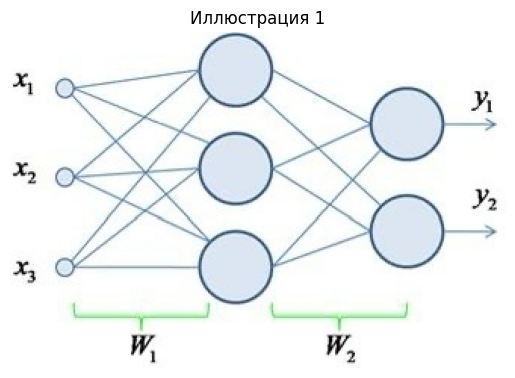

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image1 = mpimg.imread('illustrations/SGD_1.jpg')

plt.imshow(image1)
plt.axis('off')
plt.title('Иллюстрация 1')
plt.show()

C набором весов $W_1$ для первого (скрытого слоя), $W_2$ - для выходного слоя, и некоторыми функциями активации: $\sigma_1(z)$ - для нейронов первого (скрытого) слоя; $\sigma_2(z)$ - для нейронов выходного слоя. Работу такой сети математически можно записать следующим образом:

Общая формула прямого прохода (от входа до выхода):

$$
\begin{bmatrix} y_1 \\ y_2 \end{bmatrix} = \sigma_2 \left( W_2 \cdot \sigma_1 \left( W_1 \cdot \begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix} \right) \right)
$$

Матрица весов связей скрытого слоя $W_1$:

$$
W_1 = \begin{bmatrix} \omega_{11} & \omega_{12} & \omega_{13} \\ \omega_{21} & \omega_{22} & \omega_{23} \\ \omega_{31} & \omega_{32} & \omega_{33} \end{bmatrix}
$$

Матрица весов связей выходного слоя $W_2$:

$$
W_2 = \begin{bmatrix} \omega_{11} & \omega_{12} & \omega_{13} \\ \omega_{21} & \omega_{21} & \omega_{23} \end{bmatrix}
$$

Ту же самую формулу, можно кратко представить в виде:

$$
\vec{y} = f(\vec{x}; W_1, W_2)
$$

Нейронная сеть — это параметрический алгоритм. Её работа описывается функционалом:

$$
\vec{y} = f(\vec{x}; \vec{\omega}),
$$

где $\vec{\omega}$ — вектор (или матрица) всех весовых коэффициентов.

Если в нашем распоряжении будет множество различных входных данных:

$$
X^l = \begin{bmatrix} \overline{x}_1 \\ \overline{x}_2 \\ \dots \\ \overline{x}_l \end{bmatrix} = \begin{bmatrix} x_{11} & x_{12} & \dots & x_{1n} \\ x_{21} & x_{22} & \dots & x_{2n} \\ \dots & \dots & \dots & \dots \\ x_{l1} & x_{l2} & \dots & x_{ln} \end{bmatrix}
$$

С известными (требуемыми) выходными значениями:

$$
Y^l = \begin{bmatrix} \overline{y}_1 \\ \overline{y}_2 \\ \dots \\ \overline{y}_l \end{bmatrix} = \begin{bmatrix} y_{11} & y_{12} & \dots & y_{1m} \\ y_{21} & y_{22} & \dots & y_{2m} \\ \dots & \dots & \dots & \dots \\ y_{l1} & y_{l2} & \dots & y_{lm} \end{bmatrix}
$$

То под эти данные можно попытаться подобрать коэффициенты $\vec{\omega}$ функционала $f(\vec{x}; \vec{\omega})$ так, чтобы он для каждого входного вектора $\vec{x_i}$ выборки $X^l$ выдавал как можно более близкие значения к заданному вектору $\vec{y_i}$ выборки $Y^l$.

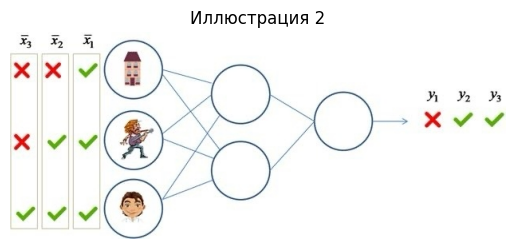

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image2 = mpimg.imread('illustrations/SGD_2.jpg')

plt.imshow(image2)
plt.axis('off')
plt.title('Иллюстрация 2')
plt.show()

Обучение — это подбор таких $\vec{\omega}$, чтобы для каждого входного образа $\vec{x_i}$ из обучающей выборки выход сети $\vec{y_i}$ был как можно ближе к целевому значению $\vec{t_i}$. Это задача обучения с учителем.

Для одного образа рассогласование измеряется функцией потерь $L_i(\vec{t}_i, \vec{y}_i)$. Для всей выборки вводится функционал качества (эмпирический риск):

$$
Q(X^l; \vec{\omega}) = \frac{1}{l} \sum_{i=1}^{l} L_i(\vec{t}_i, \vec{y}_i),
$$

где $l$ — размер выборки. Задача обучения — минимизировать $Q$.

### 2. Градиентный алгоритм

В общем виде веса обновляются по правилу:

$$
\vec{\omega}^{(n)} = \vec{\omega}^{(n-1)} - \eta \cdot \frac{dQ(X^l)}{d\vec{\omega}},
$$

где $\eta > 0$ — шаг обучения (learning rate).

Расписывая функционал $Q$, получаем:

$$
\vec{\omega}^{(n)} = \vec{\omega}^{(n-1)} - \eta \cdot \frac{1}{l} \sum_{i=1}^{l} \frac{dL_i(\vec{t}_i, \vec{y}_i)}{d\vec{\omega}}
$$

Так как выборка может быть очень большой, на практике используют стохастический градиентный спуск (SGD) — градиент считают не по всей выборке, а по случайному мини-батчу из $K$ образов:

$$
\vec{\omega}^{(n)} = \vec{\omega}^{(n-1)} - \eta \cdot \sum_{i \in K} \frac{dL_i(f(\vec{x}_i; \vec{\omega}), \vec{y}_i)}{d\vec{\omega}}
$$

### 3. Требования к функциям

Чтобы градиентный алгоритм работал, функция потерь $L$ и все функции активации должны быть дифференцируемыми. Например, пороговая функция не подходит:

$$
\sigma(z) = \begin{cases} 1, & z \ge \lambda \\ 0, & z < \lambda \end{cases}.
$$

### 4. Примеры функций потерь

Регрессия, квадратичная функция:

$$
L_i(\vec{t}_i, \vec{y}_i) = \sum_{j=1}^{m} (t_i^j - y_i^j)^2
$$

Бинарная классификация, бинарная кросс-энтропия:

$$
L_i(\vec{t}_i, \vec{y}_i) = y_i \log t_i + (1 - y_i) \log(1 - t_i)
$$

### 5. Примеры функций активации

На заре нейронных сетей, в основном, применялись:

- $\sigma(z) = \frac{1}{1 + e^{-z}}$ - сигмоидная функция;
- $\sigma(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$ - гиперболический тангенс.

А на выходном слое часто используют следующие:

- $\sigma(z)   = z$ - линейная функция активации; для задач регрессии;
- $\sigma(z)   = \frac{1}{1 + e^{-z}}$ - сигмоидная функция активации; для задач бинарной классификации;
- $\sigma(z_i) = \frac{\exp(z_i)}{\sum_{j=1}^{M} \exp(z_j)}, \quad i = 1, 2, ..., M$ - функция softmax для задач M-классовой классификации.